In [1]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import glob
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics
import yfinance as yf
import tensorflow as tf

from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.python.keras.utils import np_utils
from keras.datasets import mnist
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from prophet.plot import add_changepoints_to_plot, plot_plotly, plot_components_plotly
from prophet  import Prophet
from openpyxl import load_workbook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, ConfusionMatrixDisplay, confusion_matrix, accuracy_score, silhouette_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier


# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

2026-02-23 18:37:47.721002: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# CIFAR-10 이미지 분류 (Canadian Institute for Advanced Research)

* CIFAR-10은 10개의 클래스로 구성된 32×32 크기의 컬러 이미지 데이터셋
* 딥러닝 모델(특히 CNN) 학습에 자주 사용
 
* 캐나다 몬트리올의 CIFAR(미래를 위한 고급 연구 기구) 연구소에서 수집
* 50,000개는 훈련용, 10,000개는 테스트용으로 사용
* 각 클래스당 6,000장씩 균등 분포
 
* 클래스(10개): 비행기, 자동차, 새, 고양이, 사슴, 개, 개구리, 말, 배, 트럭

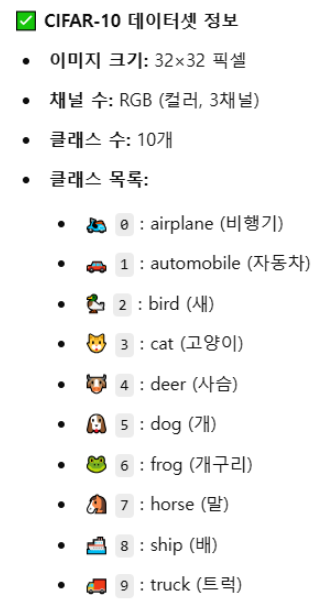


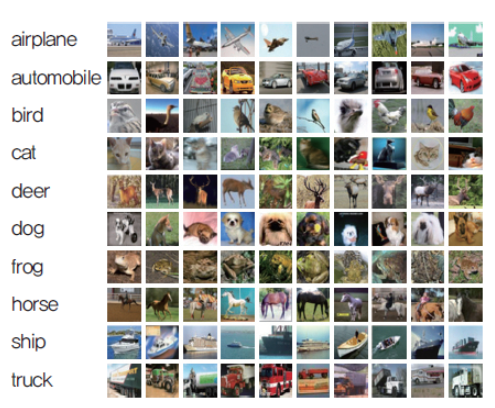

In [2]:
from keras.datasets import cifar10

In [3]:
# CIFAR-10 데이터 로드

data = np.load('../../data/cifar10_data.npz')

X_train = data['X_train']
Y_train = data['Y_train']
X_test = data['X_test']
Y_test = data['Y_test']

print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")

X_train shape: (50000, 32, 32, 3)
Y_train shape: (50000, 1)


In [4]:
print("학습 데이터:", X_train.shape)
print("테스트 데이터:", X_test.shape)

학습 데이터: (50000, 32, 32, 3)
테스트 데이터: (10000, 32, 32, 3)


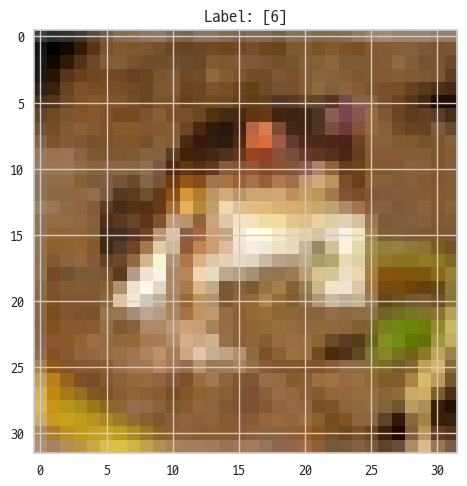

In [ ]:
# 첫 번째 이미지 출력
plt.imshow(X_train[0])
plt.title(f"Label: {Y_train[0]}")   # 6번 개구리
plt.show()

In [6]:
# 0~255 → 0~1 범위로
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# 범주형으로
Y_train = to_categorical(Y_train, 10)
Y_test = to_categorical(Y_test, 10)

print("레이블 예시 : ",Y_train[0])

레이블 예시 :  [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


## CNN 모델 생성 및 학습

In [7]:
# CNN 모델 
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')  # 출력층 (10개 클래스)
])

# 모델 컴파일
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [8]:
# 모델 학습
model.fit(X_train, Y_train, epochs=10, batch_size=64, validation_data=(X_test, Y_test))

# 모델 평가
test_loss, test_acc = model.evaluate(X_test, Y_test)
print("\nTest Accuracy:", test_acc)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.5046 - loss: 1.3920 - val_accuracy: 0.6082 - val_loss: 1.1078
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.6422 - loss: 1.0237 - val_accuracy: 0.6458 - val_loss: 1.0030
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.6901 - loss: 0.8871 - val_accuracy: 0.6963 - val_loss: 0.8889
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.7239 - loss: 0.7903 - val_accuracy: 0.6881 - val_loss: 0.8957
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.7517 - loss: 0.7127 - val_accuracy: 0.6966 - val_loss: 0.8941
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.7774 - loss: 0.6401 - val_accuracy: 0.7125 - val_loss: 0.8418
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - accuracy: 0.8020 - loss: 0.5694 - val_accuracy: 0.7061 - val_loss: 0.8823
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.8240 - loss: 0.5040 - 

## 예측 실행

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


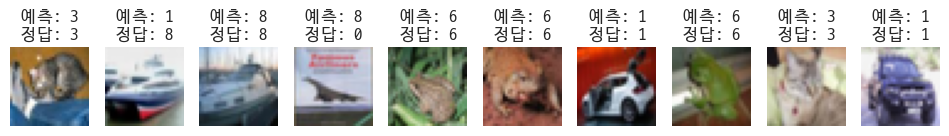

In [10]:
# 테스트 데이터에서 몇 개의 샘플을 가져오기
num_samples = 10
sample_images = X_test[:num_samples]
sample_labels = Y_test[:num_samples]

# 예측 수행
predictions = model.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(sample_labels, axis=1)

# 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, num_samples, figsize=(12, 3))
for i in range(num_samples):
    axes[i].imshow(sample_images[i])
    axes[i].axis('off')
    axes[i].set_title(f"예측: {predicted_labels[i]}\n정답: {true_labels[i]}")
plt.show()

### 데이터 증강(Data Augmentation)

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [13]:
# 데이터 증강 설정
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)    

# 증강된 데이터로 모델 학습
model.fit(datagen.flow(X_train, Y_train, batch_size=64), epochs=10, validation_data=(X_test, Y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.6766 - loss: 0.9261 - val_accuracy: 0.7206 - val_loss: 0.8477
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.6980 - loss: 0.8629 - val_accuracy: 0.7160 - val_loss: 0.8394
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.7086 - loss: 0.8325 - val_accuracy: 0.7407 - val_loss: 0.7667
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.7161 - loss: 0.8096 - val_accuracy: 0.7368 - val_loss: 0.7806
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.7204 - loss: 0.7973 - val_accuracy: 0.7354 - val_loss: 0.7895
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 85ms/step - accuracy: 0.7257 - loss: 0.7817 - val_accuracy: 0.7429 - val_loss: 0.7665
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 86ms/step - accuracy: 0.7358 - loss: 0.7571 - val_accuracy: 0.7251 - val_loss: 0.8417
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.7391 - loss: 0.7493 - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


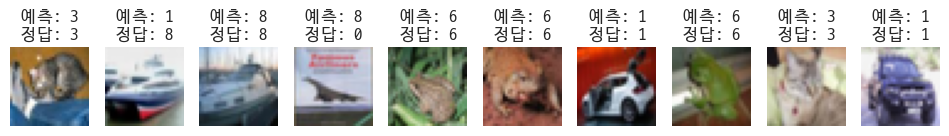

In [15]:
# 테스트 데이터에서 몇 개의 샘플을 가져오기
num_samples = 10
sample_images = X_test[:num_samples]
sample_labels = Y_test[:num_samples]

# 예측 수행
predictions = model.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(sample_labels, axis=1)

# 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, num_samples, figsize=(12, 3))
for i in range(num_samples):
    axes[i].imshow(sample_images[i])
    axes[i].axis('off')
    axes[i].set_title(f"예측: {predicted_labels[i]}\n정답: {true_labels[i]}")
plt.show()

## 새로운 이미지로 분류 예측

In [16]:
from keras.preprocessing import image

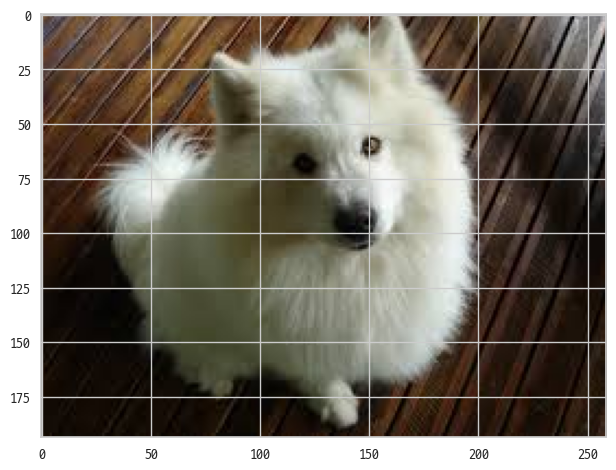

In [17]:
fname = "../../data/dog.jpg"

img = Image.open(fname)

plt.imshow(img)
plt.show()

In [18]:
img = img.convert("RGB")
img = img.resize((32,32))
new_data = np.asarray(img)
new_data = new_data.astype("float") / 255

print(f"넘파이로 변환된 입력 이미지 shape: {new_data.shape}")

# 이미지 데이터 차원 확장 (배치 크기 1 추가)
new_data = np.expand_dims(new_data, axis=0)


# 예측
predictions = model.predict(new_data)

# 예측된 클래스 번호
predicted_label = np.argmax(predictions)


# CIFAR-10 클래스 이름 목록
class_names = ["비행기", "자동차", "새", "고양이", "사슴", "개", "개구리", "말", "배", "트럭"]

# 예측된 클래스 출력
print(f"예측된 클래스 번호: {predicted_label}")
print(f"예측된 클래스 이름: {class_names[predicted_label]}")

넘파이로 변환된 입력 이미지 shape: (32, 32, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
예측된 클래스 번호: 5
예측된 클래스 이름: 개


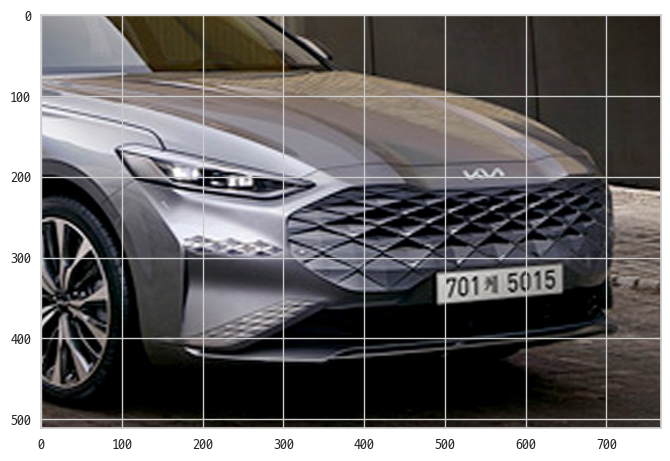

In [19]:
fname = "../../data/car001.jpg"

img = Image.open(fname)

plt.imshow(img)
plt.show()

In [20]:
img = img.convert("RGB")
img = img.resize((32,32))
new_data = np.asarray(img)
new_data = new_data.astype("float") / 255

print(f"넘파이로 변환된 입력 이미지 shape: {new_data.shape}")

# 이미지 데이터 차원 확장 (배치 크기 1 추가)
new_data = np.expand_dims(new_data, axis=0)   # 모델과 똑같은 입력 형태로 만들기 위해 배치 추가


# 예측
predictions = model.predict(new_data)    # (32, 32, 3) -> (1, 32, 32, 3)

# 예측된 클래스 번호
predicted_label = np.argmax(predictions)


# CIFAR-10 클래스 이름 목록
class_names = ["비행기", "자동차", "새", "고양이", "사슴", "개", "개구리", "말", "배", "트럭"]

# 예측된 클래스 출력
print(f"예측된 클래스 번호: {predicted_label}")
print(f"예측된 클래스 이름: {class_names[predicted_label]}")

넘파이로 변환된 입력 이미지 shape: (32, 32, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
예측된 클래스 번호: 1
예측된 클래스 이름: 자동차


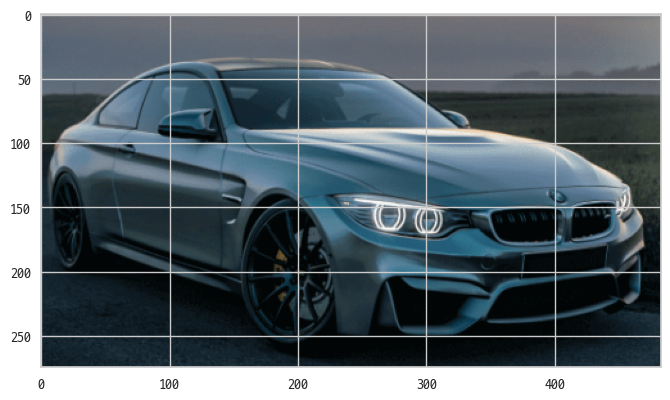

In [21]:
fname = "../../data/car002.png"

img = Image.open(fname)

plt.imshow(img)
plt.show()

In [22]:
img = img.convert("RGB")
img = img.resize((32,32))
new_data = np.asarray(img)
new_data = new_data.astype("float") / 255

print(f"넘파이로 변환된 입력 이미지 shape: {new_data.shape}")

# 이미지 데이터 차원 확장 (배치 크기 1 추가)
new_data = np.expand_dims(new_data, axis=0)   # 모델과 똑같은 입력 형태로 만들기 위해 배치 추가


# 예측
predictions = model.predict(new_data)    # (32, 32, 3) -> (1, 32, 32, 3)

# 예측된 클래스 번호
predicted_label = np.argmax(predictions)


# CIFAR-10 클래스 이름 목록
class_names = ["비행기", "자동차", "새", "고양이", "사슴", "개", "개구리", "말", "배", "트럭"]

# 예측된 클래스 출력
print(f"예측된 클래스 번호: {predicted_label}")
print(f"예측된 클래스 이름: {class_names[predicted_label]}")

넘파이로 변환된 입력 이미지 shape: (32, 32, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
예측된 클래스 번호: 1
예측된 클래스 이름: 자동차
